# Phase 4: what does the score depend on?

Phase 3 showed where attention goes. Attention, though, is the model's own account of what it looked at, not a
test of what it needs. This notebook intervenes on the input instead (removes series, removes windows, shifts
the images), re-scores, and measures what changes.

Every comparison is paired on the same 58 studies, with the Phase 2 bootstrap for intervals. Only aggregate
numbers are shown, so this notebook is safe to commit executed.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import spearmanr

ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))
import ablation as ab
import evaluation as ev
import explain as ex
import plot_style as ps
import raptor_core as rc

ps.apply()
RUN, LOCAL = ROOT / "outputs/kaggle/gold_run", ROOT / "outputs/local"
FIG = ROOT / "outputs/figures"; FIG.mkdir(parents=True, exist_ok=True)
pd.set_option("display.precision", 3)

gold = pd.read_csv(RUN / "gold_labels.csv")
Y = gold[rc.LAB].values.astype(int)
masks = np.load(RUN / "gold_masks_A.npy")
feats = np.load(RUN / "feats_A_imagenet.npy").astype(np.float32)
model, _ = rc.load_checkpoint(str(ROOT / "models/raptor_ft_coatnet_v10_full.pt"), "cpu")
logits, attn, wlogits = ex.head_outputs(model, feats)
own_slot, _ = ex.window_slots()
SLOT = {name: (a, b) for name, a, b in ex.SLOTS}

W = ev.bootstrap_weights(len(Y), 4000, seed=2646)
base_boot = np.nanmean(ev.bootstrap_aucs(Y, logits, W), axis=1)
base_macro, base_aucs = rc.macro_auc(Y, logits)


def compare(L, ref_logits=logits, ref_boot=base_boot):
    """Paired change in macro-AUC against a reference, with a 95% bootstrap interval, plus per-finding changes."""
    m, aucs = rc.macro_auc(Y, L)
    ref_m, ref_aucs = rc.macro_auc(Y, ref_logits)
    lo, hi = ev.percentile_ci(np.nanmean(ev.bootstrap_aucs(Y, L, W), axis=1) - ref_boot)
    return {"macro_auc": m, "change": m - ref_m, "ci_lo": lo, "ci_hi": hi,
            **{f: aucs[f] - ref_aucs[f] for f in rc.LAB}}


print(f"baseline (all 62 windows): macro-AUC {base_macro:.4f}")

baseline (all 62 windows): macro-AUC 0.9171


## 1. The head does not know where a window came from

The attention pooling has no positional encoding. Shuffle the 62 windows and every output stays the same.

In [2]:
perm = np.random.default_rng(0).permutation(62)
print("max logit change after shuffling windows:", np.abs(ab.head_logits(model, feats[:, perm]) - logits).max())

max logit change after shuffling windows: 1.430511474609375e-06


So when Phase 3 found medial-meniscus attention on the medial end of the stack in 57 of 58 knees, the model was
not using slice position. The two ends of the stack come in either order depending on the knee, and the head
cannot see the order anyway. It recognised medial slices from what they look like.

## 2. Taking series away

Two ways to remove a series:

- **drop**: take its windows out of the attention pool; the softmax renormalises over the rest.
- **blank**: zero its slices and rerun the pipeline, exactly what happens to a study that lacks the series.
  Only windows touching a blanked slice need the backbone; the rest reuse saved features (checked against a
  full recompute in `tests/test_ablation.py`).

In [3]:
CONDITIONS = {f"no {n}": [SLOT[n]] for n in SLOT}
CONDITIONS.update({
    "sagittal only": [SLOT["Coronal fluid"], SLOT["Coronal other"], SLOT["Axial"]],
    "coronal only": [SLOT["Sagittal fluid"], SLOT["Sagittal other"], SLOT["Axial"]],
    "axial only": [SLOT["Sagittal fluid"], SLOT["Sagittal other"], SLOT["Coronal fluid"], SLOT["Coronal other"]],
    "fluid-sensitive series only": [SLOT["Sagittal other"], SLOT["Coronal other"]],
    "non-fluid series only": [SLOT["Sagittal fluid"], SLOT["Coronal fluid"], SLOT["Axial"]],
})

cache = LOCAL / "ablation_logits.npz"
if cache.exists():
    z = np.load(cache)
    results = {str(n): z[f"l{i}"] for i, n in enumerate(z["names"])}
else:
    device = "mps" if torch.backends.mps.is_available() else "cpu"
    vols = np.load(RUN / "gold_vols_A.npy", mmap_mode="r")
    bank = ab.FeatureBank(model.to(device), feats, device)
    results = {"baseline": logits}
    for name, ranges in CONDITIONS.items():
        blanked = np.stack([bank.features(i, *ab.blank_slots(np.asarray(vols[i]), masks[i], ranges))
                            for i in range(len(Y))])
        results[f"blank: {name}"] = ab.head_logits(model.cpu(), blanked); model.to(device)
        removed = [s for s, (n, a, b) in enumerate(ex.SLOTS) if (a, b) in ranges]
        results[f"drop: {name}"] = ab.head_logits(model.cpu(), feats[:, ~np.isin(own_slot, removed)]); model.to(device)
    model.cpu()
    np.savez(cache, names=np.array(list(results)), **{f"l{i}": v for i, v in enumerate(results.values())})

table = pd.DataFrame({name: compare(L) for name, L in results.items() if name != "baseline"}).T
table[["macro_auc", "change", "ci_lo", "ci_hi"]]

,macro_auc,change,ci_lo,ci_hi
blank: no Sagittal fluid,0.899,-1.764e-02,-0.032,-0.005
drop: no Sagittal fluid,0.900,-1.720e-02,-0.031,-0.004
blank: no Sagittal other,0.915,-1.774e-03,-0.007,0.004
drop: no Sagittal other,0.915,-1.645e-03,-0.007,0.003
blank: no Coronal fluid,0.906,-1.135e-02,-0.021,-0.003
drop: no Coronal fluid,0.906,-1.151e-02,-0.022,-0.003
blank: no Coronal other,0.918,7.951e-04,-0.002,0.004
drop: no Coronal other,0.918,1.058e-03,-0.002,0.004
blank: no Axial,0.917,-5.059e-04,-0.005,0.004
drop: no Axial,0.916,-8.072e-04,-0.006,0.004


Drop and blank agree on macro-AUC to within 0.005 for every condition, and on individual findings to within
0.04. A study missing a series is scored almost as if that series' windows had never been in the pool: the
blank windows it gets instead carry little weight. From here on only the blank results are shown.

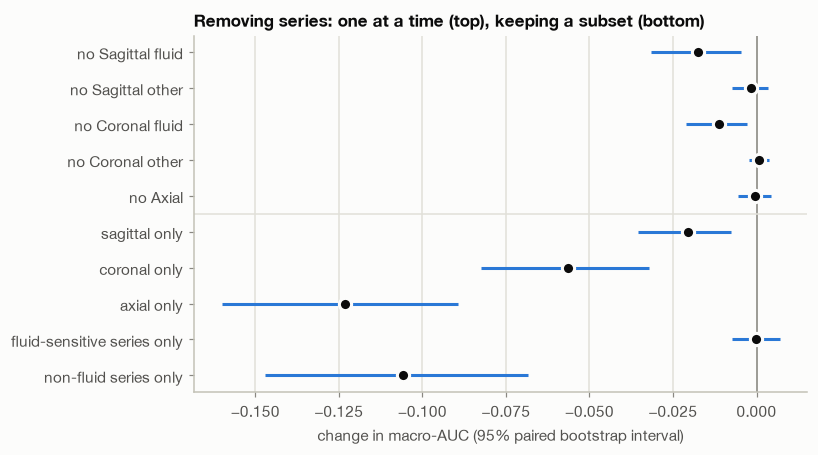

In [4]:
blank = table.loc[[f"blank: {n}" for n in CONDITIONS]]
blank.index = list(CONDITIONS)

fig, ax = plt.subplots(figsize=(7.2, 4.2))
yy = np.arange(len(blank))[::-1]
ax.hlines(yy, blank.ci_lo, blank.ci_hi, color=ps.BLUE, lw=2)
ax.scatter(blank.change, yy, s=64, color=ps.INK, edgecolor=ps.SURFACE, linewidth=2, zorder=3)
ax.axvline(0, color=ps.MUTED, lw=1)
ax.set_yticks(yy, blank.index)
ax.set_xlabel("change in macro-AUC (95% paired bootstrap interval)")
ax.grid(axis="y", visible=False)
ax.axhline(4.5, color=ps.GRID, lw=1)
ax.set_title("Removing series: one at a time (top), keeping a subset (bottom)")
fig.savefig(FIG / "phase4_series_macro.png")
plt.show()

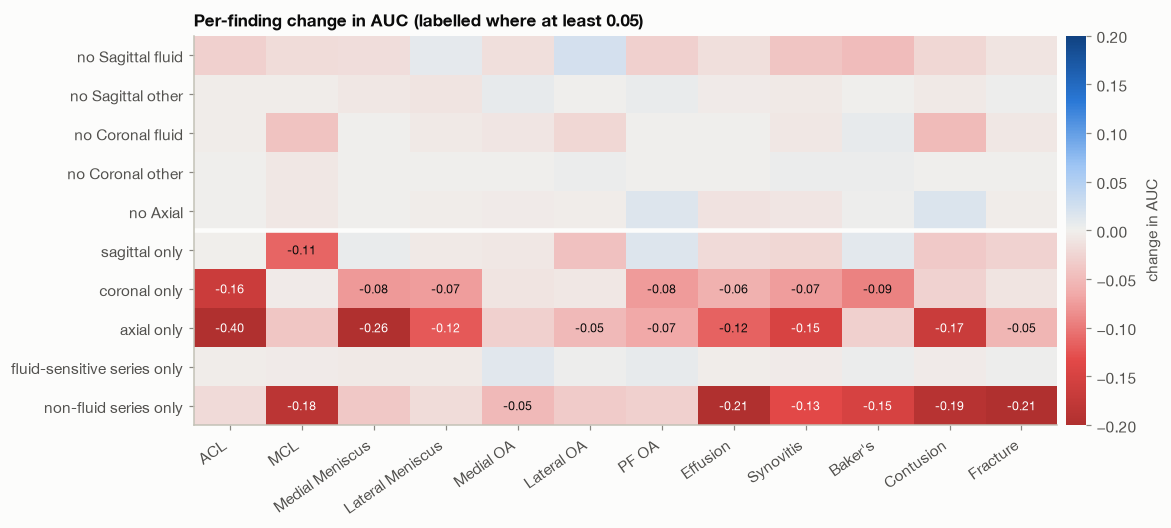

In [5]:
div = LinearSegmentedColormap.from_list("red_grey_blue",
                                        ["#b0302f", "#e34948", "#f1a9a8", "#f0efec", "#9ec5f4", "#2a78d6", "#104281"])
M = blank[rc.LAB].values.astype(float)
fig, ax = plt.subplots(figsize=(10.5, 4.6))
im = ax.imshow(M, cmap=div, vmin=-0.2, vmax=0.2, aspect="auto")
ax.set_xticks(range(len(rc.LAB)), rc.LAB, rotation=35, ha="right")
ax.set_yticks(range(len(blank)), blank.index)
ax.grid(False)
ax.axhline(4.5, color=ps.SURFACE, lw=3)
for r in range(M.shape[0]):
    for c in range(M.shape[1]):
        if abs(M[r, c]) >= 0.05:
            ax.text(c, r, f"{M[r, c]:+.2f}", ha="center", va="center", fontsize=8,
                    color="white" if abs(M[r, c]) > 0.12 else ps.INK)
cb = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.01)
cb.set_label("change in AUC", color=ps.INK_2); cb.outline.set_visible(False)
ax.set_title("Per-finding change in AUC (labelled where at least 0.05)")
fig.savefig(FIG / "phase4_series_findings.png")
plt.show()

**Reading it.**

- **No single series is indispensable.** The worst single loss is the fluid-sensitive sagittal series
  (-0.018 macro-AUC, interval -0.032 to -0.005), then fluid-sensitive coronal (-0.011). Removing the non-fluid
  sagittal series, the second coronal series or the axial series changes nothing measurable.
- **The two non-fluid series add nothing measurable at all.** Keeping only the fluid-sensitive series costs
  0.000. Phase 3 found ACL and osteoarthritis putting 23-28% of their attention on the non-fluid sagittal
  series. That attention is real but redundant.
- **Fluid-sensitive sequences are essential for fluid and marrow findings.** Without them effusion (-0.21),
  fracture (-0.21), contusion (-0.19), MCL (-0.18) and Baker's cyst (-0.15) collapse. ACL and lateral meniscus
  lose only 0.02: tears are visible on anatomy sequences too.
- **Each finding needs its plane.** Sagittal alone keeps most findings but MCL falls by 0.11: the ligament runs
  up the side of the knee and needs coronal slices. Coronal alone costs the ACL 0.16: it runs obliquely
  front-to-back and needs sagittal slices. With axial alone the ACL falls to 0.58, barely above chance.

## 3. Does attention predict what matters?

For each finding and series (60 pairs), compare the attention share from Phase 3 with two effects of blanking
that series: how much the logits move, and how much the AUC changes.

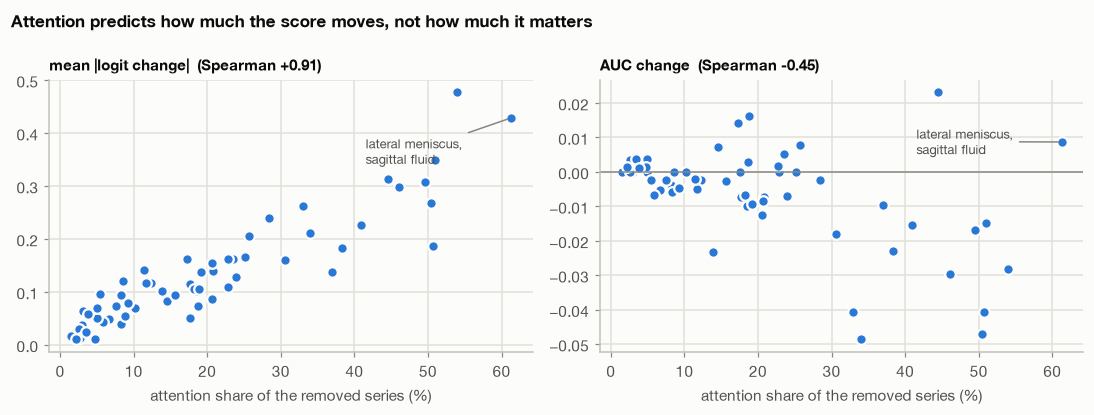

In [6]:
pairs = []
for s, (name, a, b) in enumerate(ex.SLOTS):
    L = results[f"blank: no {name}"]
    for j, f in enumerate(rc.LAB):
        pairs.append({"series": name, "finding": f, "attention share": attn[:, own_slot == s, j].sum(1).mean(),
                      "mean |logit change|": np.abs(L[:, j] - logits[:, j]).mean(),
                      "AUC change": table.loc[f"blank: no {name}", f]})
pairs = pd.DataFrame(pairs)
rho_logit = spearmanr(pairs["attention share"], pairs["mean |logit change|"]).statistic
rho_auc = spearmanr(pairs["attention share"], pairs["AUC change"]).statistic

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), sharex=True)
for ax, col, rho in [(axes[0], "mean |logit change|", rho_logit), (axes[1], "AUC change", rho_auc)]:
    ax.scatter(pairs["attention share"] * 100, pairs[col], s=48, color=ps.BLUE, edgecolor=ps.SURFACE, linewidth=1.5)
    ax.set_xlabel("attention share of the removed series (%)")
    ax.set_title(f"{col}  (Spearman {rho:+.2f})", fontsize=10)
lm = pairs[(pairs.series == "Sagittal fluid") & (pairs.finding == "Lateral Meniscus")].iloc[0]
for ax, col in [(axes[0], "mean |logit change|"), (axes[1], "AUC change")]:
    ax.annotate("lateral meniscus,\nsagittal fluid", (lm["attention share"] * 100, lm[col]),
                xytext=(-95, -8 if col == "AUC change" else -30), textcoords="offset points", fontsize=8.5,
                color=ps.INK_2, arrowprops=dict(arrowstyle="-", color=ps.MUTED, lw=1))
axes[1].axhline(0, color=ps.MUTED, lw=1)
fig.suptitle("Attention predicts how much the score moves, not how much it matters", x=0.01, ha="left",
             fontsize=11, fontweight="bold")
fig.tight_layout()
fig.savefig(FIG / "phase4_attention_vs_damage.png")
plt.show()

Attention share predicts how far the logits move almost perfectly (Spearman +0.91): take away a series with a
lot of attention and the numbers change a lot. It predicts the damage to *ranking* only moderately (-0.45).

The lateral meniscus shows why. It puts 61% of its attention on the fluid-sensitive sagittal series, and removing
that series moves its logits more than any other pair except the ACL's, yet its AUC goes *up* slightly. The coronal slices show
the same tears, so every study's score shifts but the order of studies holds. Attention measures influence, not
necessity, and the difference is redundancy.

## 4. A shortcut the model could have learned

Fourteen of the 58 studies have no second coronal series, and they are not a random fourteen:

In [7]:
missing = masks[:, 44:52].sum(1) == 0
mix = pd.DataFrame({"no 2nd coronal (14)": Y[missing].mean(0) * 100,
                    "has it (44)": Y[~missing].mean(0) * 100}, index=rc.LAB).T
mix.round(0)

,ACL,MCL,Medial Meniscus,Lateral Meniscus,Medial OA,Lateral OA,PF OA,Effusion,Synovitis,Baker's,Contusion,Fracture
no 2nd coronal (14),57.0,21.0,36.0,29.0,0.0,14.0,14.0,57.0,29.0,21.0,57.0,50.0
has it (44),36.0,14.0,48.0,43.0,34.0,20.0,43.0,61.0,52.0,20.0,25.0,25.0


None of the 14 has medial osteoarthritis (against 34% of the rest), and contusion and fracture are twice as
common. That looks like an acute-trauma protocol that skips a sequence. A model trained on data with the same
pattern could learn "blank windows mean trauma". Two checks:

In [8]:
has = ~missing
L = results["blank: no Coronal other"]
shift = pd.DataFrame({
    "mean logit shift when blanked (44 studies that have it)": (L[has] - logits[has]).mean(0),
    "blank window's own logit": wlogits[missing][:, (ex.CENTRES >= 45) & (ex.CENTRES <= 50)].mean((0, 1)),
    "typical window logit (median)": np.median(wlogits.reshape(-1, len(rc.LAB)), axis=0),
    "attention on the six blank windows (%)": attn[missing][:, (ex.CENTRES >= 45) & (ex.CENTRES <= 50)].sum(1).mean(0) * 100,
}, index=rc.LAB)
shift.round(2)

,mean logit shift when blanked (44 studies that have it),blank window's own logit,typical window logit (median),attention on the six blank windows (%)
ACL,-0.01,-0.22,-0.07,0.91
MCL,-0.06,-0.61,-0.21,3.75
Medial Meniscus,-0.00,-1.58,-0.07,1.01
Lateral Meniscus,-0.08,-1.43,-0.02,1.84
Medial OA,-0.06,-1.66,-0.58,1.77
Lateral OA,-0.09,-0.43,-0.36,3.55
PF OA,-0.04,-1.19,-0.39,3.25
Effusion,0.04,1.72,-0.16,1.56
Synovitis,0.01,0.67,-0.11,0.92
Baker's,-0.00,-0.11,-0.78,1.84


Blanking the series in the 44 studies that have it moves contusion and fracture by 0.00 logits on average, and
no finding by more than 0.09. The model has not turned "series missing" into evidence of trauma.

The reason is worth seeing, because it is not that blank windows are neutral. A black window's own logit is well
*above* the typical window's for effusion, synovitis, Baker's cyst and fracture: taken alone, it votes for them.
It never gets to cast that vote, because the attention layer gives the six blank windows only 0.5-4% of the
weight. The protection comes from attention, and a model with a flatter attention would carry this bias.

## 5. How many windows does it need?

Phase 0 found 8 evenly spaced windows scoring 0.84 and 24 scoring 0.92. Is it the number of windows or which ones?
Compare evenly spaced subsets with random ones (30 random draws per size, a different draw for each study).

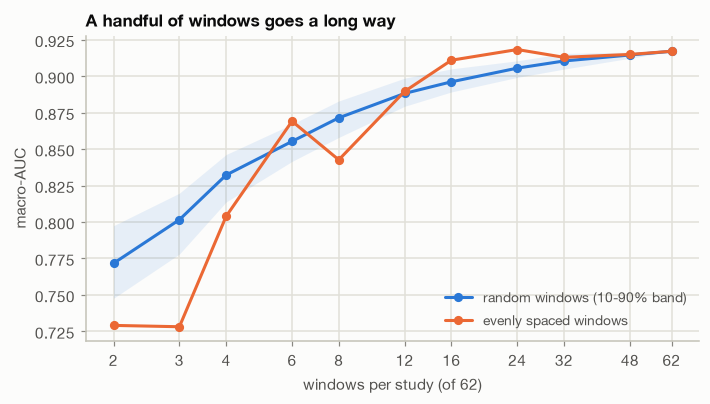

,evenly spaced,random (mean),random p10,random p90
windows,,,,
2,0.729,0.772,0.748,0.797
3,0.728,0.802,0.778,0.820
4,0.804,0.832,0.814,0.846
6,0.869,0.855,0.842,0.867
8,0.843,0.871,0.858,0.883
12,0.890,0.888,0.879,0.899
16,0.911,0.896,0.889,0.905
24,0.918,0.906,0.899,0.911
32,0.913,0.910,0.905,0.916


In [9]:
rng = np.random.default_rng(0)
rows = []
for k in [2, 3, 4, 6, 8, 12, 16, 24, 32, 48, 62]:
    idx = [c - 1 for c in rc.eval_centers(masks[0], k)]
    draws = []
    for _ in range(30):
        sel = np.stack([rng.choice(62, k, replace=False) for _ in range(len(Y))])
        draws.append(rc.macro_auc(Y, ab.head_logits(model, np.take_along_axis(feats, sel[:, :, None], 1)))[0])
    rows.append({"windows": k, "evenly spaced": rc.macro_auc(Y, ab.head_logits(model, feats[:, idx]))[0],
                 "random (mean)": np.mean(draws), "random p10": np.percentile(draws, 10),
                 "random p90": np.percentile(draws, 90)})
curve = pd.DataFrame(rows).set_index("windows")

fig, ax = plt.subplots(figsize=(7.2, 3.6))
ax.fill_between(curve.index, curve["random p10"], curve["random p90"], color=ps.BLUE, alpha=0.1, lw=0)
ax.plot(curve.index, curve["random (mean)"], color=ps.BLUE, marker="o", markersize=5, label="random windows (10-90% band)")
ax.plot(curve.index, curve["evenly spaced"], color=ps.ORANGE, marker="o", markersize=5, label="evenly spaced windows")
ax.set_xscale("log", base=2)
ax.set_xticks(curve.index, curve.index)
ax.set_xlabel("windows per study (of 62)")
ax.set_ylabel("macro-AUC")
ax.set_title("A handful of windows goes a long way")
ax.legend(loc="lower right", fontsize=9)
fig.savefig(FIG / "phase4_window_count.png")
plt.show()
curve.round(3)

Two random windows per study already reach 0.77, eight reach 0.87 and sixteen 0.90. Beyond about 24 there is
little left to gain. The evenly spaced curve is jagged at small sizes (8 windows score below 6) because a
fixed spacing decides which series get sampled at all. That is why Phase 0's single number at 8 windows looked
so bad. Random subsets, averaged, show the smooth underlying trend.

## 6. Acquisition-like shifts

Scanners and protocols differ. Two shifts that happen in real data, applied to every slice:

- **Zoom** 1.25x and 1.5x. Series with a field of view under 140 mm are already magnified by the preprocessing
  (16 of the series used here, by up to 1.73x).
- **Contrast**: remap intensities through $x^{\gamma}$ with $\gamma$ = 0.67 (brighter mid-tones) or 1.5 (darker).

These change every window, so all 3,596 windows were re-encoded (`scripts/robustness_features.py`). The
reference is the unperturbed stacks encoded the same way, so precision differences cancel.

In [10]:
conds = ["zoom_1.25", "zoom_1.5", "gamma_0.67", "gamma_1.5"]
ref_logits = ab.head_logits(model, np.load(LOCAL / "feats_mps_base.npy").astype(np.float32))
ref_boot = np.nanmean(ev.bootstrap_aucs(Y, ref_logits, W), axis=1)
print(f"re-encoded baseline macro-AUC {rc.macro_auc(Y, ref_logits)[0]:.4f} (saved features: {base_macro:.4f})")
shift_rows = {}
for c in conds:
    Lc = ab.head_logits(model, np.load(LOCAL / f"feats_{c}.npy").astype(np.float32))
    shift_rows[c] = {**compare(Lc, ref_logits, ref_boot),
                     "mean |prob change|": np.abs(ab.sigmoid(Lc) - ab.sigmoid(ref_logits)).mean()}
shifts = pd.DataFrame(shift_rows).T
shifts[["macro_auc", "change", "ci_lo", "ci_hi", "mean |prob change|"]]

re-encoded baseline macro-AUC 0.9170 (saved features: 0.9171)


,macro_auc,change,ci_lo,ci_hi,mean |prob change|
zoom_1.25,0.915,-0.002,-0.017,1.140e-02,0.047
zoom_1.5,0.899,-0.018,-0.036,-4.518e-04,0.075
gamma_0.67,0.913,-0.004,-0.011,2.549e-03,0.027
gamma_1.5,0.911,-0.006,-0.018,3.495e-03,0.026


In [11]:
shifts[rc.LAB].astype(float).round(3)

,ACL,MCL,Medial Meniscus,Lateral Meniscus,Medial OA,Lateral OA,PF OA,Effusion,Synovitis,Baker's,Contusion,Fracture
zoom_1.25,-0.004,-0.020,0.005,0.004,-0.002,-0.031,0.012,-0.004,0.008,0.005,-0.013,0.012
zoom_1.5,-0.022,-0.091,-0.005,-0.009,-0.008,-0.017,-0.024,0.004,-0.011,0.018,-0.054,0.000
gamma_0.67,0.001,-0.005,-0.004,-0.004,-0.009,0.006,0.001,0.005,-0.006,0.004,-0.018,-0.021
gamma_1.5,-0.006,-0.052,0.002,-0.004,0.000,-0.010,-0.001,0.001,-0.002,-0.005,0.001,0.006


**Reading it.**

- **Contrast changes barely matter.** Brightening or darkening the mid-tones moves macro-AUC by -0.004 and
  -0.006, both well inside the noise. The remapping is monotone, so every edge and tissue boundary stays in
  place, and the model evidently relies on those more than on absolute brightness.
- **Mild zoom leaves the ranking alone but moves the probabilities.** At 1.25x macro-AUC changes by -0.002,
  yet predicted probabilities shift by about 5 percentage points on average. Rankings survive, calibration does
  not: a decision threshold tuned on one field of view would not transfer to another.
- **Strong zoom costs real performance.** At 1.5x macro-AUC falls by 0.018 (the interval just excludes zero),
  concentrated in MCL (-0.09) and contusion (-0.05). Only the central 93 mm survives, which crops the sides of the
  knee where the MCL runs and much of the bone marrow lies. The 16 real series with a field of view under 140 mm
  are magnified by up to 1.73x, so for those studies the MCL score deserves less trust.

## 7. Summary

| Question | Answer |
|---|---|
| Does the head use slice position? | No. It is permutation-invariant, so anatomy is recognised from pixels |
| Most important series | Fluid-sensitive sagittal (-0.018 when removed), then fluid-sensitive coronal (-0.011) |
| Least important | Non-fluid sagittal, second coronal, axial: no measurable loss alone. Both non-fluid series together: 0.000 |
| What needs fluid-sensitive sequences | Effusion, fracture, contusion, MCL, Baker's cyst (-0.15 to -0.21 without them) |
| Plane dependence | MCL needs coronal (-0.11 with sagittal only). ACL needs sagittal (-0.16 with coronal only, 0.58 with axial only) |
| Is attention a measure of importance? | It predicts how far logits move (rho = +0.91), much less how much ranking suffers (rho = -0.45) |
| Missing-series shortcut? | Not used: at most 0.09 logit shift, because blank windows get little attention |
| Windows needed | 2 random windows give 0.77, 16 give 0.90, little gain past 24 |
| Acquisition shifts | Contrast: negligible. Zoom 1.25x: ranking intact, probabilities shift 5 points. Zoom 1.5x: -0.018, MCL -0.09 |

Three lessons:

1. **To learn what a model needs, intervene.** Attention and saliency show influence. Removing inputs shows
   necessity, and the two differ wherever the inputs are redundant.
2. **The redundancy here is clinically sensible.** Fluid-sensitive series in two planes, plus axial, carry
   essentially everything: 42 of 64 slices, a third fewer windows to encode. Whether that holds beyond these 58
   studies needs the leaderboard, and Phase 2 says differences under about 0.012 cannot be seen here anyway.
3. **Robustness is about calibration as much as ranking.** Zoom that leaves AUC untouched still moves
   probabilities by several points. AUC alone would never show it.